<a href="https://colab.research.google.com/github/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_1_nlp_intro/HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv('./data/tweet_sentiment_train.csv.zip')

raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [2]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [3]:
# remove rows with missing values
raw_df = raw_df.dropna()
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
dtypes: object(4)
memory usage: 1.0+ MB


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [4]:
raw_df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


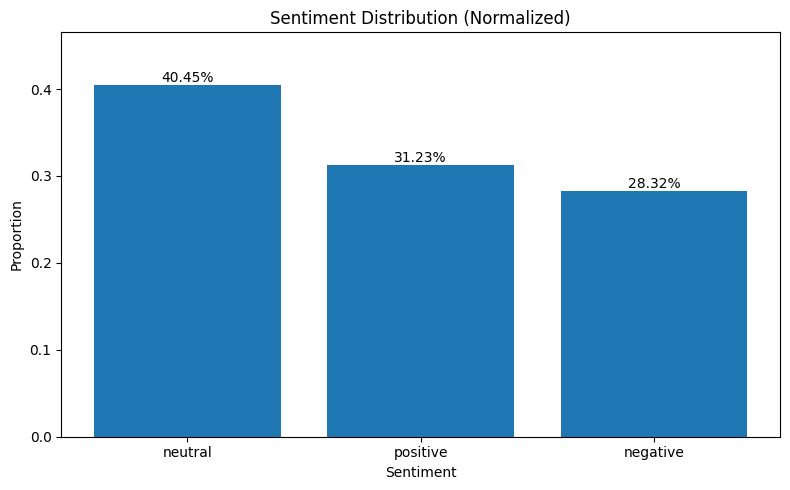

In [5]:
import matplotlib.pyplot as plt

# Compute distribution
sentiment_dist = raw_df['sentiment'].value_counts(normalize=True)

plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_dist.index, sentiment_dist.values)

plt.title('Sentiment Distribution (Normalized)')
plt.xlabel('Sentiment')
plt.ylabel('Proportion')

# Value labels
for bar, value in zip(bars, sentiment_dist.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.2%}',
        ha='center',
        va='bottom'
    )

plt.ylim(0, sentiment_dist.max() * 1.15)
plt.tight_layout()
plt.show()

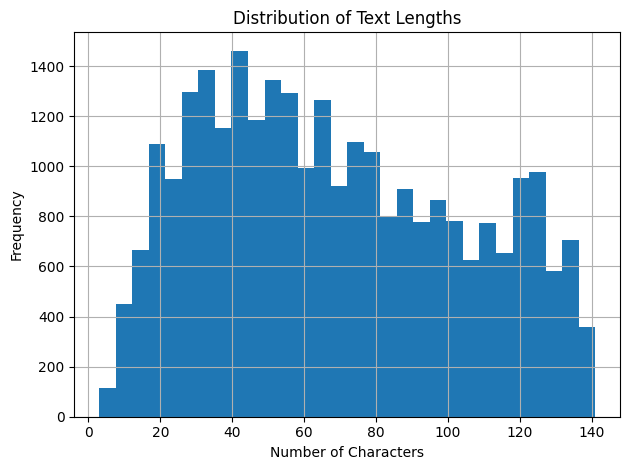

In [6]:
text_length = pd.Series(raw_df['text'].apply(lambda t: len(t)))

ax = text_length.hist(bins=30)
ax.set_title('Distribution of Text Lengths')
ax.set_xlabel('Number of Characters')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [7]:
text_length.describe()

,text
count,27480.000000
mean,68.330022
std,35.603870
min,3.000000
25%,39.000000
50%,64.000000
75%,97.000000
max,141.000000


<span style="display: block; background-color: #f60">

* The dataset shows **no significant class imbalance**: *neutral* accounts for \~40% of samples, while *positive* (\~31%) and *negative* (\~28%) are relatively close in proportion. This distribution is sufficiently balanced for training standard classifiers without requiring resampling techniques.
* Post lengths range from **3 to 141 characters**, with a clear primary peak around **40 characters**. The shape loosely resembles a Poisson-like distribution, but the presence of a secondary peak near **120 characters** suggests a **bimodal pattern**, likely indicating two typical writing styles or message formats within the data.

</span>


### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




#### Punctuations analysis & pre-processing

In [8]:
# first vectorize all possbile punctuations used to see the list
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_puncts = CountVectorizer(
    token_pattern=r"[^\w\s]+",   # sequences of punctuation
    lowercase=False,
    max_features=300,
)

vectorizer_puncts.fit(raw_df.text)

vectorizer_puncts.get_feature_names_out()

array(['!', '!!', '!!!', '!!!!', '!!!!!', '!!!!!!', '!!!!!!!', '!!!!!!!!',
       '!!!!!!!!!', '!!!!!!!!!!', '!!!!!!!!!!!', '!!!!!!!!!!!!',
       '!!!!!!!!!!!!!', '!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!',
       '!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!',
       '!!!!!!!!!!!!!!!!!!!!!!', '!!!)', '!!!..', '!!!...', "!!'", '!!)',
       '!!...', '!!?', '!!??', "!'", '!)', '!),', '!).', '!*', '!,',
       '!,.', '!.', '!..', '!...', '!.....', '!:', '!?', '!?!', '!?!?',
       '!?!?!', '!?!?!?!?', '!??', '!]', '!`', '#', '#****', '$', '$$',
       '$$$', '$.', '%', '%),', '%.', '&', '&&', "'", "'!", "'!!!", "''",
       "',", "'-", "'.", "'...", "'....", "'?", '(', '($', '(&', "('",
       '((', '(((', '()', '(*', '(****', '(****)', '(:', '(?)', ')', ')!',
       '))', ')))', '),', ').', ')..', ')...', '):', ')?', '*', "*'",
       '**', '***', '****', '****!', '****!!', '****!!!!', '*****',
       '****,', '****-', '****.', '****..', '****...', '****....',
       '****?', '****`', '*-*', '*.

#### Numbers analysis & pre-processing

In [9]:
# next check numbers related stuff
vectorizer_num = CountVectorizer(
    token_pattern=r"\b(?:\d{1,3}%|\d+/\d+|[a-z]*\d+[a-z]*)\b",  # try to find something meaninful related to numbers
    lowercase=False,
    max_features=1000,
)

vectorizer_num.fit(raw_df.text)

vectorizer_num.get_feature_names_out()

array(['0', '00', '000', '000th', '00am', '00pm', '01', '02', '024',
       '02mxjj', '03', '04', '04/05', '05', '05/30', '05/31', '05ixbj',
       '06', '07', '08', '09', '1', '1/2', '10', '100', '1000',
       '100000000000000000000000000000000000', '100th', '101', '102',
       '1030', '1034415', '104', '105', '106', '107', '108', '109',
       '1095', '10am', '10days', '10jsepj', '10k', '10m', '10mins',
       '10mm', '10pm', '10th', '10yr', '11', '11/20', '110', '1100',
       '1115', '1123', '1130', '1155hours', '116', '117th', '11am', '11e',
       '11pm', '11th', '11w', '12', '120', '121908inlove', '123', '128',
       '12am', '12hr', '12k', '12lbs', '12p', '12seconds', '12st', '12th',
       '12yr', '13', '130', '1300', '131', '1313', '132', '13341015518',
       '135', '13576/658166', '138', '13pdrmj', '13th', '13tolife', '14',
       '140', '143', '144', '145', '147', '14m', '14mph', '14th', '14yr',
       '15', '150', '1500', '1500ft', '1505', '153bpm', '154upj',
       '15

<span style="display: block; background-color: #f60">

* The raw text contains a large amount of **noise from numbers, punctuation, IDs, and random character sequences**. Most of this does not carry semantic or sentiment value and will be **removed during tokenization** to reduce vocabulary pollution and sparsity.
* Certain punctuation patterns, however, act as **strong sentiment signals in short texts**. Instead of dropping them, they will be **normalized and preserved** under canonical tokens:

  * **ELLIPSIS** — sequences of dots (`..`, `...`, `....`) indicating hesitation, trailing thought, or subdued emotion
  * **EXCL** — repeated exclamation marks (`!`, `!!`, `!!!`) expressing strong emotion or emphasis
  * **QUEST** — repeated question marks (`?`, `??`, `???`) indicating confusion, disbelief, or frustration
  * **MIXED_QE** — mixed `?!` patterns expressing emotional confusion, shock, or disbelief
  * **SMILE** — emoticons with positive mouth shapes (`:)`, `:D`, `:>`, `:-*`) indicating positive emotion
  * **SAD_FACE** — emoticons with clearly sad mouth shapes (`:(`, `:<`, `:[`, `:{`) indicating negative emotion
  * **NEUTRAL_FACE** — emoticons with flat or skeptical mouth shapes (`:/`, `:\`, `:-|`, `:|`) indicating neutral, awkward, or skeptical emotion
* Numeric tokens are mostly noisy, but a small subset behaves like **meaningful words** (e.g., `2day`, `4ever`, `24/7`, `100`, `404`). A **whitelist of such tokens** will be preserved during tokenization, while all other numbers will be removed.

</span>


#### Pre-process steps implementation

In [10]:
NUM_KEEP = {
    # emphasis / rating
    '100', '1000', '100x', '10/10', '1/2',

    # time-of-day (mood context)
    '4am', '5am', '6am', '7am', '8am', '9am',
    '10am', '11am', '1am', '2am', '3am',
    '4pm', '5pm', '6pm', '7pm', '8pm', '9pm', '10pm', '11pm',

    # short time expressions
    '24/7', '24hrs', '24hr', '48hours', '60s',

    # slang / leetspeak / SMS language
    '2day', '2moro', '2morrow', '2mrw', '2nite', '2night', '2nyt',
    '4ever', 'l8', 'l8r', 'l8rs', 'l8ter',
    'gr8', 'b4', 'w8', 'm8', 'h8', 'g2g',

    # common “word-like” number tokens
    '3d', '3ds', 'mp3', 'mp4', 'ps3',

    # culturally meaningful numbers
    '404', '911', '420', '365',

    # durations people complain about
    '10mins', '15mins', '20mins', '30mins',
    '1hr', '2hrs', '3hrs', '6hrs',

    # ages / years-as-words (often sentiment context)
    '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s',
}

In [11]:
import re

SMILE_RE = re.compile(r"""
    (?:
        [:;]      # eyes
        -?        # optional nose
        [)\]>D*]  # happy mouth
    )
""", re.VERBOSE)

SAD_FACE_RE = re.compile(r"""
    (?:
        [:;]      # eyes
        -?        # optional nose
        [(\[<{]   # clearly sad mouth
    )
""", re.VERBOSE)

NEUTRAL_FACE_RE = re.compile(r"""
    (?:
        [:;]      # eyes
        -?        # optional nose
        [|/\\]    # neutral / skeptical mouth
    )
""", re.VERBOSE)


def pre_normalize(text):
    text = SMILE_RE.sub(" SMILE ", text)
    text = SAD_FACE_RE.sub(" SAD_FACE ", text)
    text = NEUTRAL_FACE_RE.sub(" NEUTRAL_FACE ", text)

    text = re.sub(r"[!?]{2,}", " MIXED_QE ", text)
    text = re.sub(r"\.{2,}", " ELLIPSIS ", text)
    text = re.sub(r"!{1,}", " EXCL ", text)
    text = re.sub(r"\?{1,}", " QUEST ", text)
    return text

In [12]:
# test it
pre_normalize(';))'), pre_normalize(':]'), pre_normalize(':>'), pre_normalize(':-*'),

(' SMILE )', ' SMILE ', ' SMILE ', ' SMILE ')

In [13]:
# test it
pre_normalize(':-/'), pre_normalize(':-|'), pre_normalize(':/'), pre_normalize('://'), pre_normalize(':<'),

(' NEUTRAL_FACE ',
 ' NEUTRAL_FACE ',
 ' NEUTRAL_FACE ',
 ' NEUTRAL_FACE /',
 ' SAD_FACE ')

In [14]:
# nltk downloads
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

#### Tokenize step implementation

In [15]:
# imports & implement tokenize function
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import re

word_re = re.compile(r"^[a-zA-Z]{2,}$")
stemmer = SnowballStemmer(language='english')
english_stopwords = stopwords.words('english')

def tokenize(text):
    text = pre_normalize(text.lower())
    tokens = word_tokenize(text)

    result = []
    for t in tokens:
        if t in {"ELLIPSIS","EXCL","QUEST","MIXED_QE","SMILE","SAD_FACE","NEUTRAL_FACE"}:
            result.append(t)
        elif t in NUM_KEEP:
            result.append(t)
        elif word_re.match(t) and t not in english_stopwords:
            result.append(stemmer.stem(t))

    return result

#### Vectorization

In [22]:
vectorizer = CountVectorizer(
    analyzer='word',
    lowercase=True,
    tokenizer=tokenize,
    max_features=2000,      # keep only 2000 most popular as features
)

In [23]:
%%time
vectorizer.fit(raw_df.text)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


CPU times: user 7.67 s, sys: 11.4 ms, total: 7.68 s
Wall time: 7.76 s


CountVectorizer(max_features=2000,
                tokenizer=<function tokenize at 0x7868fbb72d40>)

In [24]:
vectorizer.get_feature_names_out()[:100]

array(['1/2', '100', '2day', '2moro', '2nite', '3d', '4am', '9am',
       'ELLIPSIS', 'EXCL', 'MIXED_QE', 'NEUTRAL_FACE', 'QUEST',
       'SAD_FACE', 'SMILE', 'abl', 'absolut', 'abt', 'ac', 'accept',
       'access', 'accid', 'accident', 'accord', 'account', 'ace', 'ach',
       'across', 'act', 'action', 'activ', 'actual', 'ad', 'adam', 'add',
       'addict', 'address', 'admit', 'adopt', 'ador', 'advanc',
       'adventur', 'advic', 'afford', 'afraid', 'afternoon', 'age', 'ago',
       'agre', 'ah', 'aha', 'ahaha', 'ahead', 'ahh', 'ahhh', 'ahhhh',
       'aim', 'aint', 'air', 'airport', 'al', 'ala', 'alarm', 'album',
       'alcohol', 'alex', 'aliv', 'allergi', 'allow', 'almost', 'alon',
       'along', 'alot', 'alreadi', 'alright', 'also', 'although', 'alway',
       'amaz', 'america', 'american', 'ami', 'amus', 'andi', 'ang',
       'angel', 'angri', 'anim', 'ankl', 'anna', 'anniversari', 'announc',
       'annoy', 'anoth', 'answer', 'anybodi', 'anymor', 'anyon', 'anyth',
       'a

In [25]:
%%time
inputs = vectorizer.transform(raw_df.text)

CPU times: user 7.67 s, sys: 11.2 ms, total: 7.68 s
Wall time: 7.77 s


In [ ]:
inputs.shape

(27480, 2000)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



#### Encode target

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(raw_df.sentiment)
# negative -> 0
# neutral  -> 1
# positive -> 2

In [27]:
y_encoded[:10], raw_df.sentiment[:10]

(array([1, 0, 0, 0, 0, 1, 2, 1, 1, 2]),
 0     neutral
 1    negative
 2    negative
 3    negative
 4    negative
 5     neutral
 6    positive
 7     neutral
 8     neutral
 9    positive
 Name: sentiment, dtype: object)

#### Split Data to train / test

In [34]:
from sklearn.model_selection import train_test_split
import numpy as np

indices = np.arange(len(raw_df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
)

X_train_bow = inputs[train_idx]
X_test_bow  = inputs[test_idx]

y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]

X_train_bow.shape, X_test_bow.shape, y_train.shape, y_test.shape

((21984, 2000), (5496, 2000), (21984,), (5496,))

#### Logistic Regression

In [35]:
# train log reg
from sklearn.linear_model import LogisticRegression

MAX_ITER = 1000

model_lr = LogisticRegression(max_iter=MAX_ITER, solver='sag', random_state=42)


In [36]:
%%time
model_lr.fit(X_train_bow, y_train)

CPU times: user 2.8 s, sys: 2.68 ms, total: 2.8 s
Wall time: 3.95 s


LogisticRegression(max_iter=1000, random_state=42, solver='sag')

In [37]:
# make log reg prediction
preds_train_lr = model_lr.predict(X_train_bow)
preds_test_lr = model_lr.predict(X_test_bow)

# decode target
preds_train_lr = le.inverse_transform(preds_train_lr)
preds_test_lr = le.inverse_transform(preds_test_lr)

#### Decision Tree

In [ ]:
# train decision tree
from sklearn.tree import DecisionTreeClassifier

# use ccp_alpha to avoid too much overfitting
model_dt = DecisionTreeClassifier(ccp_alpha=1e-4, random_state=42)

In [ ]:
%%time
model_dt.fit(X_train_bow, y_train)

CPU times: user 4.85 s, sys: 7.91 ms, total: 4.85 s
Wall time: 5.2 s


DecisionTreeClassifier(ccp_alpha=0.0001, random_state=42)

In [ ]:
# make tree prediction
preds_train_dt = model_dt.predict(X_train_bow)
preds_test_dt = model_dt.predict(X_test_bow)

# decode target
preds_train_dt = le.inverse_transform(preds_train_dt)
preds_test_dt = le.inverse_transform(preds_test_dt)

#### Random Forest

In [ ]:
# train random forest
from sklearn.ensemble import RandomForestClassifier

# use ccp_alpha to avoid too much overfitting
model_rf = RandomForestClassifier(n_estimators=50, ccp_alpha=1e-6, random_state=42)

In [ ]:
%%time
model_rf.fit(X_train_bow, y_train)

CPU times: user 19.3 s, sys: 126 ms, total: 19.4 s
Wall time: 19.7 s


RandomForestClassifier(ccp_alpha=1e-06, n_estimators=50, random_state=42)

In [ ]:
# make r forest prediction
preds_train_rf = model_rf.predict(X_train_bow)
preds_test_rf = model_rf.predict(X_test_bow)

# decode target
preds_train_rf = le.inverse_transform(preds_train_rf)
preds_test_rf = le.inverse_transform(preds_test_rf)

#### XGBoost

In [ ]:
# train xgboost with some hyperparams recommended by openAI chat model
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',

    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    colsample_bytree=0.3,

    early_stopping_rounds=10,
    random_state=42,
    n_jobs=-1
)



In [ ]:
%%time
model_xgb.fit(
    X_train_bow,
    y_train,
    eval_set=[(X_test_bow, y_test)],
    verbose=False
)

CPU times: user 5min 39s, sys: 429 ms, total: 5min 40s
Wall time: 3min 18s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.3, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1, num_class=3, ...)

In [ ]:
# make xgb prediction
preds_train_xgb = model_xgb.predict(X_train_bow)
preds_test_xgb = model_xgb.predict(X_test_bow)

# decode target
preds_train_xgb = le.inverse_transform(preds_train_xgb)
preds_test_xgb = le.inverse_transform(preds_test_xgb)

#### Evaluate models test predictions

In [38]:
y_test_decoded = le.inverse_transform(y_test)

Logistic Regression:

              precision    recall  f1-score   support

    negative       0.71      0.60      0.65      1572
     neutral       0.64      0.73      0.68      2236
    positive       0.76      0.72      0.74      1688

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



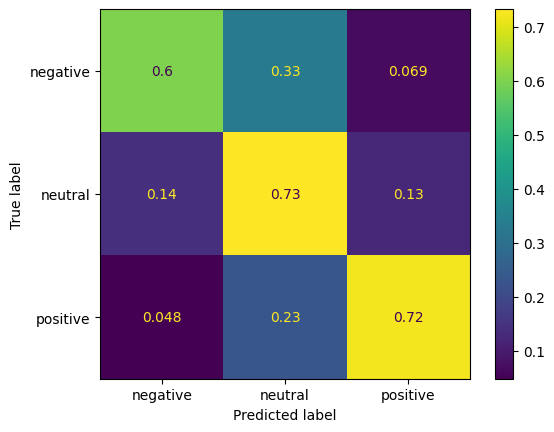

In [39]:
# compare metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("Logistic Regression:\n")
print(classification_report(y_test_decoded, preds_test_lr))
ConfusionMatrixDisplay.from_predictions(y_test_decoded, preds_test_lr, normalize='true');

Decision Tree:

              precision    recall  f1-score   support

    negative       0.70      0.56      0.62      1572
     neutral       0.65      0.73      0.69      2236
    positive       0.73      0.74      0.74      1688

    accuracy                           0.69      5496
   macro avg       0.69      0.68      0.68      5496
weighted avg       0.69      0.69      0.68      5496



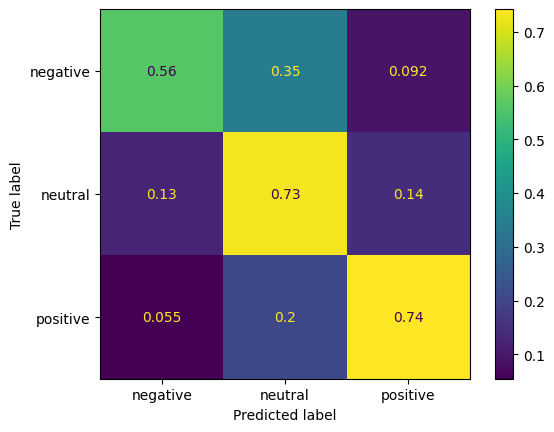

In [ ]:
print("Decision Tree:\n")
print(classification_report(y_test_decoded, preds_test_dt))
ConfusionMatrixDisplay.from_predictions(y_test_decoded, preds_test_dt, normalize='true');

Random Forest:

              precision    recall  f1-score   support

    negative       0.69      0.61      0.65      1572
     neutral       0.67      0.68      0.68      2236
    positive       0.71      0.77      0.74      1688

    accuracy                           0.69      5496
   macro avg       0.69      0.69      0.69      5496
weighted avg       0.69      0.69      0.69      5496



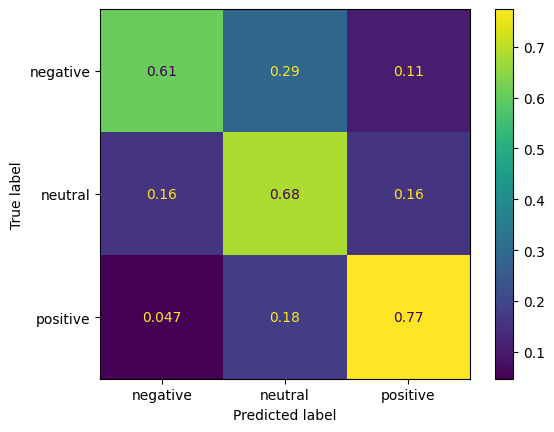

In [ ]:
print("Random Forest:\n")
print(classification_report(y_test_decoded, preds_test_rf))
ConfusionMatrixDisplay.from_predictions(y_test_decoded, preds_test_rf, normalize='true');

XGBoost:

              precision    recall  f1-score   support

    negative       0.77      0.54      0.63      1572
     neutral       0.64      0.80      0.71      2236
    positive       0.77      0.73      0.75      1688

    accuracy                           0.70      5496
   macro avg       0.73      0.69      0.70      5496
weighted avg       0.72      0.70      0.70      5496



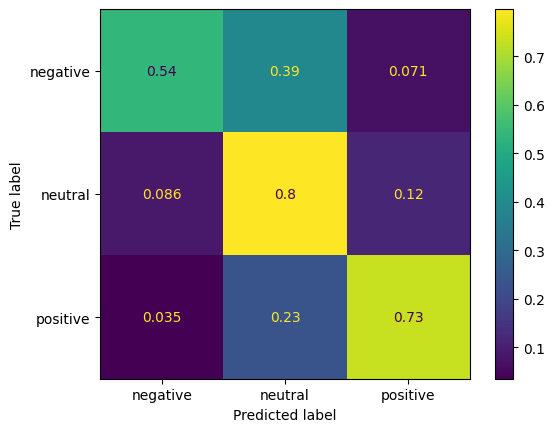

In [ ]:
print("XGBoost:\n")
print(classification_report(y_test_decoded, preds_test_xgb))
ConfusionMatrixDisplay.from_predictions(y_test_decoded, preds_test_xgb, normalize='true');

<span style="display: block; background-color: #f60">

* Four models were trained on the same BoW features: Logistic Regression, Decision Tree, Random Forest, and XGBoost.

* All achieved very similar accuracy (~0.69–0.70), showing that **feature engineering had more impact than model complexity**.

* XGBoost delivered the best overall metrics, especially for the **neutral** class, but had lower recall for **negative** sentiment.

* Logistic Regression showed the **most balanced performance across all classes** and matched or outperformed the tree-based models.

* Given similar results, **Logistic Regression is the optimal practical choice** due to simplicity, speed, and interpretability.

</span>


### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [ ]:
feature_importance = pd.Series(model_lr.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance.head(10), feature_importance.tail(10)

(sad           2.675815
 suck          2.409084
 sorri         2.287433
 hate          2.278207
 bore          2.244643
 fail          2.065945
 miss          2.049739
 shame         2.018326
 disappoint    2.004337
 unfortun      1.986988
 Name: imp, dtype: float64,
 enjoy     -1.584967
 welcom    -1.708631
 smile     -1.730280
 amaz      -1.824883
 congrat   -1.942417
 thank     -2.027176
 cute      -2.042794
 love      -2.097630
 glad      -2.183278
 awesom    -2.450983
 Name: imp, dtype: float64)

In [ ]:
custom_tokens = [
    'ELLIPSIS', 'EXCL', 'MIXED_QE',
    'NEUTRAL_FACE', 'QUEST', 'SAD_FACE', 'SMILE'
]

feature_importance.loc[custom_tokens].sort_values(ascending=False)

,imp
SAD_FACE,1.210378
NEUTRAL_FACE,0.553480
ELLIPSIS,0.102790
MIXED_QE,-0.010328
QUEST,-0.095382
EXCL,-0.115738
SMILE,-0.866640


<span style="display: block; background-color: #f60">

* Logistic Regression coefficients show clear and interpretable sentiment patterns.

* The strongest positive weights are words like *“sad”, “hate”, “suck”, “fail”, “disappoint”*, which strongly indicate negative sentiment.

* The strongest negative weights are words like *“awesome”, “love”, “thank”, “smile”, “amazing”*, which indicate positive sentiment.

* Custom engineered features also behave consistently: **SAD_FACE** strongly aligns with negative sentiment, while **SMILE** aligns with positive sentiment. Punctuation-based signals (e.g. **ELLIPSIS**, **QUEST**, **EXCL**) have weaker but still meaningful influence.

* Overall, the most influential tokens are emotionally meaningful words and emoticons, confirming that the model learned real sentiment structure rather than noise.

</span>


### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



#### TF-IDF Vectorization

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf_vectorizer = TfidfVectorizer(
    analyzer='word',
    lowercase=True,
    tokenizer=tokenize,     # use the same tokenize funciton as in BoW
    max_features=2000,      # keep only 2000 most popular as features
)

In [17]:
%%time
tfidf_vectorizer.fit(raw_df.text)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


CPU times: user 7.29 s, sys: 14 ms, total: 7.3 s
Wall time: 7.38 s


TfidfVectorizer(max_features=2000,
                tokenizer=<function tokenize at 0x7868fbb72d40>)

In [18]:
tfidf_vectorizer.get_feature_names_out()[:100]

array(['1/2', '100', '2day', '2moro', '2nite', '3d', '4am', '9am',
       'ELLIPSIS', 'EXCL', 'MIXED_QE', 'NEUTRAL_FACE', 'QUEST',
       'SAD_FACE', 'SMILE', 'abl', 'absolut', 'abt', 'ac', 'accept',
       'access', 'accid', 'accident', 'accord', 'account', 'ace', 'ach',
       'across', 'act', 'action', 'activ', 'actual', 'ad', 'adam', 'add',
       'addict', 'address', 'admit', 'adopt', 'ador', 'advanc',
       'adventur', 'advic', 'afford', 'afraid', 'afternoon', 'age', 'ago',
       'agre', 'ah', 'aha', 'ahaha', 'ahead', 'ahh', 'ahhh', 'ahhhh',
       'aim', 'aint', 'air', 'airport', 'al', 'ala', 'alarm', 'album',
       'alcohol', 'alex', 'aliv', 'allergi', 'allow', 'almost', 'alon',
       'along', 'alot', 'alreadi', 'alright', 'also', 'although', 'alway',
       'amaz', 'america', 'american', 'ami', 'amus', 'andi', 'ang',
       'angel', 'angri', 'anim', 'ankl', 'anna', 'anniversari', 'announc',
       'annoy', 'anoth', 'answer', 'anybodi', 'anymor', 'anyon', 'anyth',
       'a

In [20]:
%%time
tfidf_inputs = tfidf_vectorizer.transform(raw_df.text)

CPU times: user 9.74 s, sys: 30.8 ms, total: 9.77 s
Wall time: 12 s


In [21]:
tfidf_inputs.shape

(27480, 2000)

#### train /test split

In [40]:
X_train_tfidf = tfidf_inputs[train_idx]
X_test_tfidf  = tfidf_inputs[test_idx]

X_train_tfidf.shape, X_test_tfidf.shape, y_train.shape, y_test.shape

((21984, 2000), (5496, 2000), (21984,), (5496,))

#### TF-IDF trained based Model

In [43]:
from sklearn.linear_model import LogisticRegression

MAX_ITER = 1000

model_lr_tfidf = LogisticRegression(max_iter=MAX_ITER, solver='sag', random_state=42)


In [44]:
%%time
model_lr_tfidf.fit(X_train_tfidf, y_train)

CPU times: user 490 ms, sys: 1.01 ms, total: 491 ms
Wall time: 508 ms


LogisticRegression(max_iter=1000, random_state=42, solver='sag')

In [45]:
# make log reg prediction
preds_train_lr_tfidf = model_lr_tfidf.predict(X_train_tfidf)
preds_test_lr_tfidf = model_lr_tfidf.predict(X_test_tfidf)

# decode target
preds_train_lr_tfidf = le.inverse_transform(preds_train_lr_tfidf)
preds_test_lr_tfidf = le.inverse_transform(preds_test_lr_tfidf)

TF-IDF based Logistic Regression:

              precision    recall  f1-score   support

    negative       0.71      0.58      0.64      1572
     neutral       0.63      0.75      0.69      2236
    positive       0.77      0.71      0.73      1688

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.69      0.69      0.69      5496



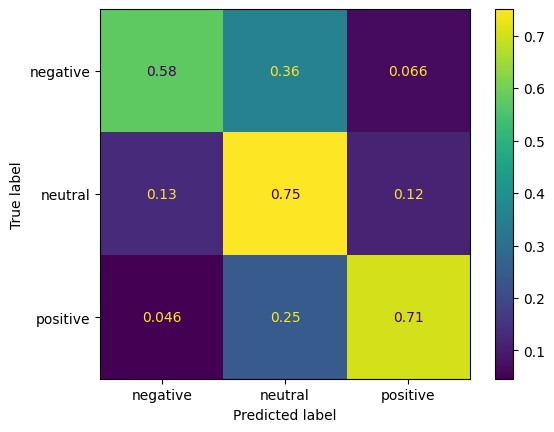

In [47]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_test_decoded = le.inverse_transform(y_test)

print("TF-IDF based Logistic Regression:\n")
print(classification_report(y_test_decoded, preds_test_lr_tfidf))
ConfusionMatrixDisplay.from_predictions(y_test_decoded, preds_test_lr_tfidf, normalize='true');

#### TF-IDF feature importance

In [48]:
feature_importance_tfidf = pd.Series(model_lr_tfidf.coef_[0], index=tfidf_vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_tfidf.head(10), feature_importance_tfidf.tail(10)

(sad      5.125830
 miss     4.824784
 suck     4.261857
 hate     4.249016
 sorri    4.194540
 bore     3.735084
 fail     3.512400
 sick     3.281499
 hurt     3.234604
 poor     3.203410
 Name: imp, dtype: float64,
 better   -2.258691
 amaz     -2.384408
 cute     -2.448346
 nice     -2.494492
 glad     -2.735505
 great    -2.773289
 hope     -3.132881
 awesom   -3.560616
 thank    -3.894189
 love     -4.658843
 Name: imp, dtype: float64)

In [52]:
custom_tokens = [
    'ELLIPSIS', 'EXCL', 'MIXED_QE',
    'NEUTRAL_FACE', 'QUEST', 'SAD_FACE', 'SMILE'
]

feature_importance_tfidf.loc[custom_tokens].sort_values(ascending=False)

,imp
SAD_FACE,1.397732
NEUTRAL_FACE,0.566538
ELLIPSIS,0.435892
MIXED_QE,-0.161162
QUEST,-0.488558
EXCL,-0.528611
SMILE,-1.636398


<span style="display: block; background-color: #f60">

**Conclusions - BoW vs TF-IDF**

* **TF-IDF shows more stable quality** - slightly better neutral recall with the same overall F1.
* Feature weights are **more meaningful** - sentiment words dominate instead of frequent words.
* Custom tokens are **used effectively** (`SAD_FACE`, `SMILE`, punctuation signals gain real impact).
* TF-IDF is **more robust to noise and word repetition**.
* Leads to **better generalization** on unseen texts.

**Final choice**

* **TF-IDF** for the final solution.
* BoW remains a good baseline, but TF-IDF suits sentiment analysis better.

</span>


### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [78]:
# Build a dataframe of mistakes
errors_df = pd.DataFrame({
    "text": raw_df.iloc[test_idx].text.values,
    "raw_id": test_idx,
    "true": y_test_decoded,
    "pred": preds_test_lr_tfidf
})

errors_df["is_error"] = errors_df.true != errors_df.pred
errors = errors_df[errors_df.is_error].copy()

errors.head()

,text,raw_id,true,pred,is_error
1,"--of them kinda turns me off of it all. And then I buy more of them and dig a deeper hole, etc. ;;",10413,negative,neutral,True
8,"OHSHNAPSSS. is she pissed at blair as usual ? hahah. & yeeeah, i bake cookies",579,neutral,negative,True
21,I wish I had company,2830,negative,neutral,True
22,i`m on my mobile so it won`t let me but i can`t stop thinking about you ;)x,21209,negative,neutral,True
26,"Intel gfx driver situation much better with recent upgrades. kernel 2.6.30rc4 and driver from git: Suspend working again, fewer mem leaks",16792,negative,neutral,True


In [74]:
errors.shape

(1720, 5)

In [79]:
raw_df.iloc[2830]

,2831
textID,9c56dcbab3
text,I wish I had company
selected_text,I wish I had company
sentiment,negative


In [58]:
# See where the model fails
pd.crosstab(errors.true, errors.pred, normalize='index')

pred,negative,neutral,positive
true,,,
negative,0.000000,0.845345,0.154655
neutral,0.528674,0.000000,0.471326
positive,0.157258,0.842742,0.000000


In [70]:
# Inspect typical error texts

# Show full text without truncation
pd.set_option('display.max_colwidth', None)

errors[(errors.true=='negative') & (errors.pred=='neutral')].sample(10).text

,text
468,no turkey leg? i can`t believe it!
5074,i can`t vote for her i`m #frustraded :@
598,"Hmmm...chinese delivery it is. Altho, how will I order? I CAN`T TALK!"
3140,honestly i cannot figure this twitter thing out
4745,Getting AxKit running on Ubuntu 8.04 is making my head explode.
587,has has an ok day with jo. She bit me and now its bruised.
4848,WHY DO I EVEN TRY... WHEN DEEP DOWN INSIDE I KNO THERE PAIN ON THE OTHER SIDE
4019,Gahh ! This weather sucksss !
4805,why are matters of the heart so complicated?
94,"_xo wicked , what time you leaving? how come you cant stay the night"


In [62]:
errors[(errors.true=='positive') & (errors.pred=='neutral')].sample(10).text

,text
1779,I did?! yay! Where did I get that extra ï¿½300 from? Hmm.. anyway I`m going to be partying hard when I get it
3926,think you should catch up on your sleep befor you go back to uni haha goodnight<3
3606,"A mocha at 12:30am? My, youï¿½re brave"
5340,true. i think its important 2 be sensitive 2 it when we relate 2 others. empathy. a reminder we cant judge a book by a cover
4431,call me later so i can tell you all about the weekend. Easier over phone.
3292,baby I`m in maryland I`m NOT gonna make it BUT I will see ur sexy **** next sat in camden VIP....come early n hang!!!!!
1710,Looking forward to a short work week followed by a mini-vacation in Clemson
1223,i just downloaded Bonnie and Clyde by Beyonce and Jay-Z...an old fav
2600,y do i only have 2 people following me people follow me please x
3359,i looooove me some star trek. runs in the family


In [63]:
errors[(errors.true=='neutral') & (errors.pred=='positive')].sample(10).text

,text
488,Off to bed. Only one more day left at school before i get to go on holidays. Yay!! Finally. I am getting sick of school... LOL!
796,The hair looks sicckkkk. Happy mothers day to all the mothers!
3475,Watching 'P.S. I love you'. Eating chinese food. What else is there to do when you`re home alone on a Friday night!
2915,oh no this week is just a bad one for everyone. i love you & your pretty face & youre going to do fantastic in concert tonight
1278,"Hehehe I didn`t really know that! Well, use your blog or Twitter to suggest interesting topics for ppl to engage in"
1971,Is not looking forward to the LSAT
4367,"polyester, protester, quester, semester, sequester...hope this helps"
2092,sorry missed your post earlier about Edinburgh. I am biased towards its awesomeness! Glad you enjoyed your visit
4187,"Wah, my fav whattaburger location is closing on the 31st. ****. Good thing I`m moving. **** Mon/fri won`t be the same"
2764,"I know, I stink at birthdays sorry bra, hope you`re having fun anyhow, in spite of me!"


In [71]:
errors[(errors.true=='neutral') & (errors.pred=='negative')].sample(10).text

,text
2434,"no wayyy, that`s too funny. well he sure is missing out, but ever since you left, i feel i am too when is your next visit?"
631,Today more sore than surgery day. Glad I took extra sick day. Full recovery expected after 6 weeks. Calling lawn service firms today
5426,"actually, i really do. mostly when i forget to take off my makeup before bed"
3168,think 2 to start off with but a house that can fit 4 - or we may go the whole hog and get 4.... not sure yet
3706,"forgot my macbook`s recharger, that means nothing but Pratchett for me today"
1599,another letter for you - this one car insurance - ouch
2218,"arg..tried one pic, but she moved so i failed to save it...then they never showed her feet again but they were purty!"
1483,Hi Bruce I am trying to eat healthy! It`s kinda scary when I read 'Eat this Not that' maggots and rat hair in our food
3847,The Good: I drank Jager and licked a hot asian girl`s foot. The Bad: I was reminded once again that I will never get asian girls ever.
4156,What the hell Ross?! Where is Hugh Laurie! He was supposed to be on tonights show


<span style="display: block; background-color: #f60">

* **Strong emotion without explicit sentiment words → predicted as neutral**

  * Many *negative* and *positive* texts rely on tone, capitalization, sarcasm, or context rather than clear sentiment words.
  * Examples: *“WHY DO I EVEN TRY…”*, *“I CAN’T TALK!”*, *“this weather sucksss !”*.
  * Model misses **intensity**, **elongations**, **caps**, and **sarcasm**.

* **Neutral texts with sentiment words → predicted as positive/negative**

  * Presence of words like *love, glad, sick, funny, good* causes misclassification.
  * Examples: informational or mixed statements containing sentiment vocabulary.
  * Model over-trusts **individual tokens** without understanding context.

* **Sarcasm and mixed sentiment are a major failure case**

  * Sentences with both positive and negative signals confuse the model.
  * Examples: *“Yay!! … I am getting sick of school”*, *“The Good: … The Bad: …”*.

* **Informal language, slang, elongations, and misspellings reduce signal quality**

  * *sucksss, looooove, sicckkkk, cant, wont* weaken token matching.

* **Contextual meaning is lost in bag-of-words style features**

  * Phrases like *“not looking forward”*, *“missing out”*, *“can’t believe it”* are not captured as single sentiment units.

---

**Ways to Improve Classification Quality**

1. **Add n-grams (bigrams/trigrams) to TF-IDF**

   * Capture phrases like *“not good”*, *“can’t believe”*, *“looking forward”*.

2. **Improve normalization**

   * Handle elongations, slang, capitalization, and common misspellings.

3. **Add features for intensity and structure**

   * Caps ratio, repeated letters, exclamation/question count, sarcasm patterns.

</span>

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model